In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [15]:
df = pd.read_csv('Customer Churn.csv')

In [89]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2741,1724-BQUHA,Male,Yes,No,No,5,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.50,477.70,Yes
1806,8966-KZXXA,Male,No,Yes,Yes,36,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.10,930.95,No
3013,2065-MMKGR,Female,No,No,No,29,Yes,Yes,DSL,No,...,No,No,Yes,Yes,One year,Yes,Credit card (automatic),71.00,2080.10,No
3078,5277-ZLOOR,Female,Yes,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,85.55,187.45,Yes
335,4322-RCYMT,Male,No,Yes,Yes,68,Yes,Yes,DSL,No,...,Yes,Yes,No,Yes,One year,Yes,Bank transfer (automatic),75.80,5293.95,Yes


In [17]:
df.shape

(7043, 21)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

#Replacing blank spaces in total charges by 0 as tenure is 0 and no total charges are recorded 

In [23]:
df['TotalCharges'] = df['TotalCharges'].replace({' ': '0'})
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [26]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(0)

In [30]:
# also checking for primary key
df['customerID'].duplicated().sum()

np.int64(0)

#Converting senior citizen (0 and 1) to (yes and no) to make it easier to understand

In [32]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1:'Yes', 0:'No'})

In [34]:
df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

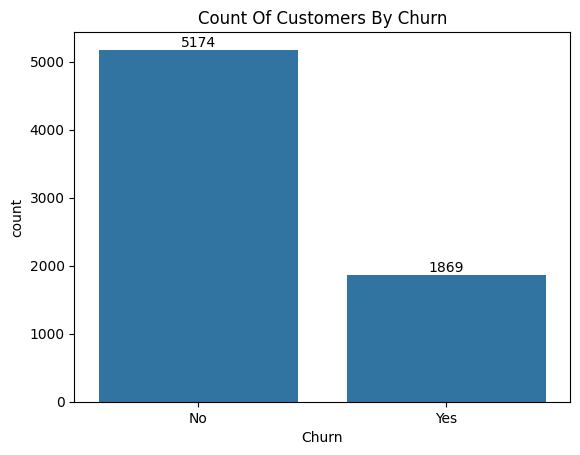

In [62]:
ax = sns.countplot(x = 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title('Count Of Customers By Churn')
plt.show()

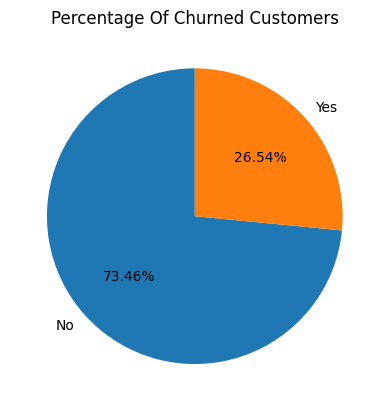

In [61]:
gb = df['Churn'].value_counts()
plt.pie(gb, labels = gb.index, startangle = 90, autopct = '%1.2f%%')
plt.title('Percentage Of Churned Customers')
plt.show()

# Observation: 
* **Significant Churn Rate:** Approximately **26.54%** of the total customer base has churned out. 
* **Business Impact:** Losing over a quarter of the customer base indicates a noticeable retention issue that requires deeper investigation into why these customers are leaving.

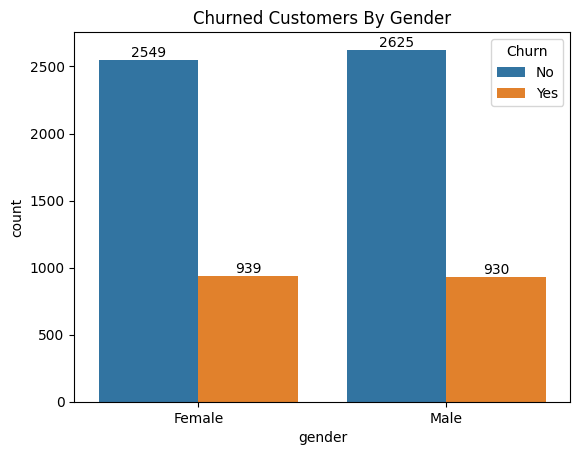

In [68]:
ax = sns.countplot(x = 'gender', hue = 'Churn', data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churned Customers By Gender')
plt.show() 

# Observation: 
* **Gender is not a driving factor for churn:** The distribution of churned versus retained customers is nearly identical between males and females. 
* **Insight:** Gender does not play a significant role in a customer's decision to leave the company, suggesting that churn triggers are universal across both demographics.

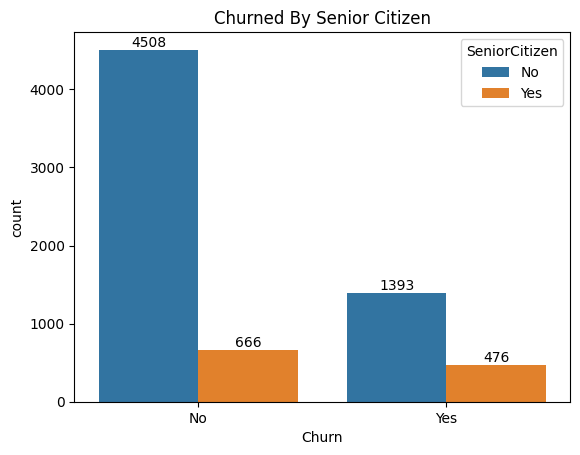

In [70]:
ax = sns.countplot(x = 'Churn', hue = 'SeniorCitizen', data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churned By Senior Citizen')
plt.show()

In [72]:
round(pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize = 'index') * 100, 2)

Churn,No,Yes
SeniorCitizen,,
No,76.39,23.61
Yes,58.32,41.68


# Observation:
* **High-Risk Demographic:** Senior citizens exhibit an alarmingly higher churn rate (**41.68%**) compared to younger customers (**23.61%**).
* **Strategic Takeaway:** While seniors make up a smaller portion of the overall customer base, they are nearly twice as likely to leave, indicating a critical need for age targeted retention strategies (e.g., simplified plan structures or dedicated support).

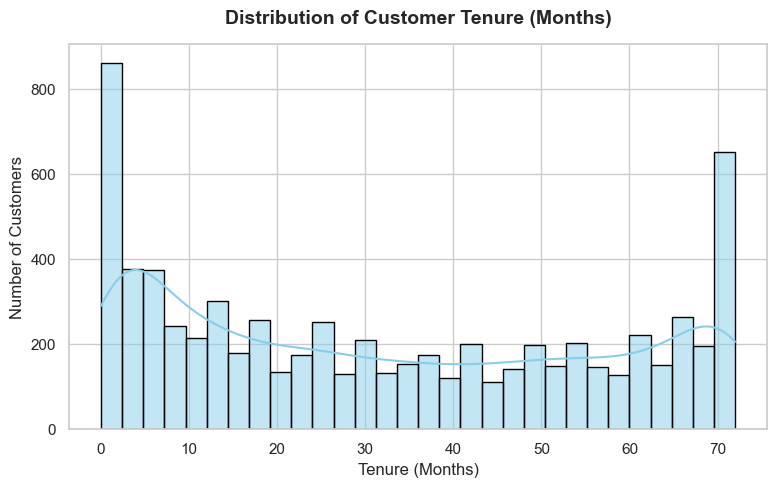

In [79]:
# Set a clean grid style
sns.set_theme(style="whitegrid")

# Create a styled histogram with a kernel density estimate (KDE) line
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='skyblue', edgecolor='black')

# Add clear, descriptive labels and titles
plt.title('Distribution of Customer Tenure (Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

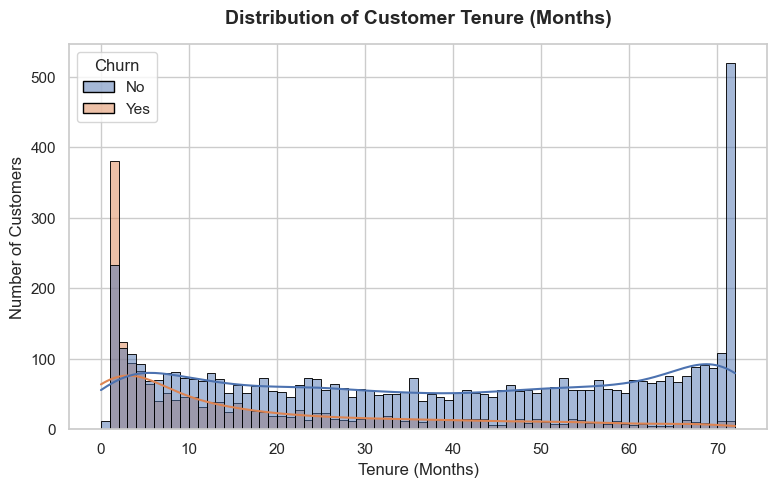

In [81]:
# Set a clean grid style
sns.set_theme(style="whitegrid")

# Create a styled histogram with a kernel density estimate (KDE) line
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='tenure', hue ='Churn', bins=72, kde=True, color='skyblue', edgecolor='black')

# Add clear, descriptive labels and titles
plt.title('Distribution of Customer Tenure (Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.show()

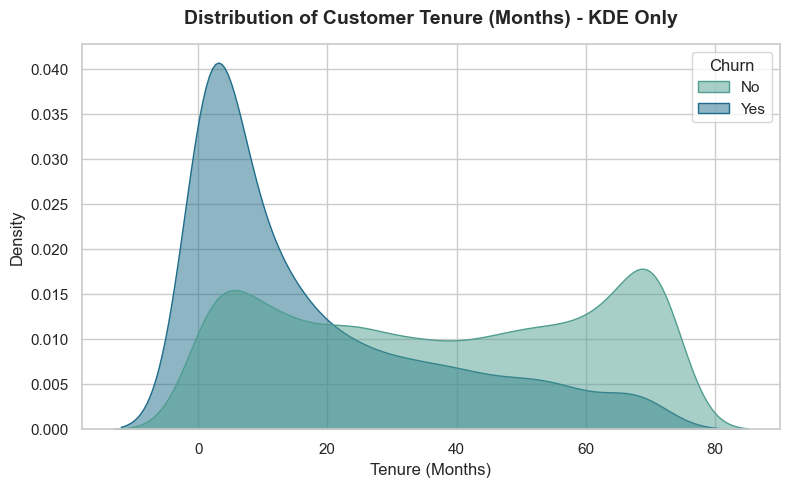

In [83]:
# Set a clean grid style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

# Use kdeplot instead of histplot to ONLY show the lines
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest', alpha=0.5)

# Add clear, descriptive labels and titles
plt.title('Distribution of Customer Tenure (Months) - KDE Only', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

# Observation:
* **High Early-Stage Risk:** Customer churn is heavily concentrated within the first few months of joining (0–10 months).
* **Retention Pattern:** Once a customer crosses the critical 1-year mark, their likelihood of churning drops drastically, leading to a highly stable, long-term loyal customer segment.

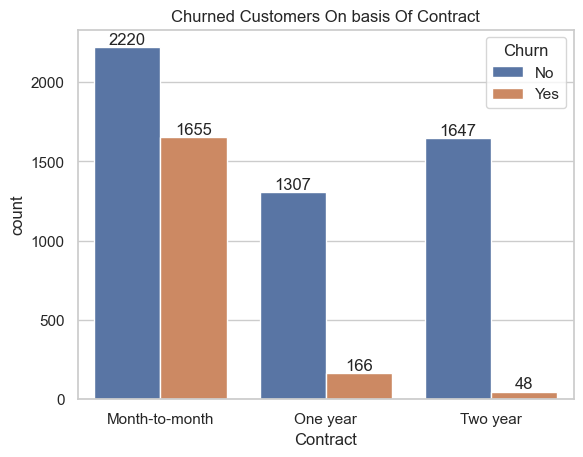

In [87]:
sns.set_theme(style = 'whitegrid')
ax = sns.countplot(x = 'Contract', hue = 'Churn', data = df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Churned Customers On basis Of Contract')
plt.show()

### # 📝 Observations & Solutions

* **The Problem (Contract-Type Risk):** Customers on **Month-to-month** contracts have an alarmingly high churn rate, making up the vast majority of our lost customers (1,655 churned vs. 2,220 retained). Conversely, **One-year** and **Two-year** contracts show exceptional loyalty, with almost negligible churn rates (166 and 48 drop-offs respectively).

* **The Strategy (Retention Solutions):**
  * **Incentivize Long-Term Commitment:** Offer targeted discounts or introductory price drops to migrate month-to-month users onto 1-year or 2-year agreements.
  * **Enhance the Short-Term Experience:** Investigate the month-to-month customer experience to provide better support or perks, smoothing out friction points during their critical first few months.

In [91]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

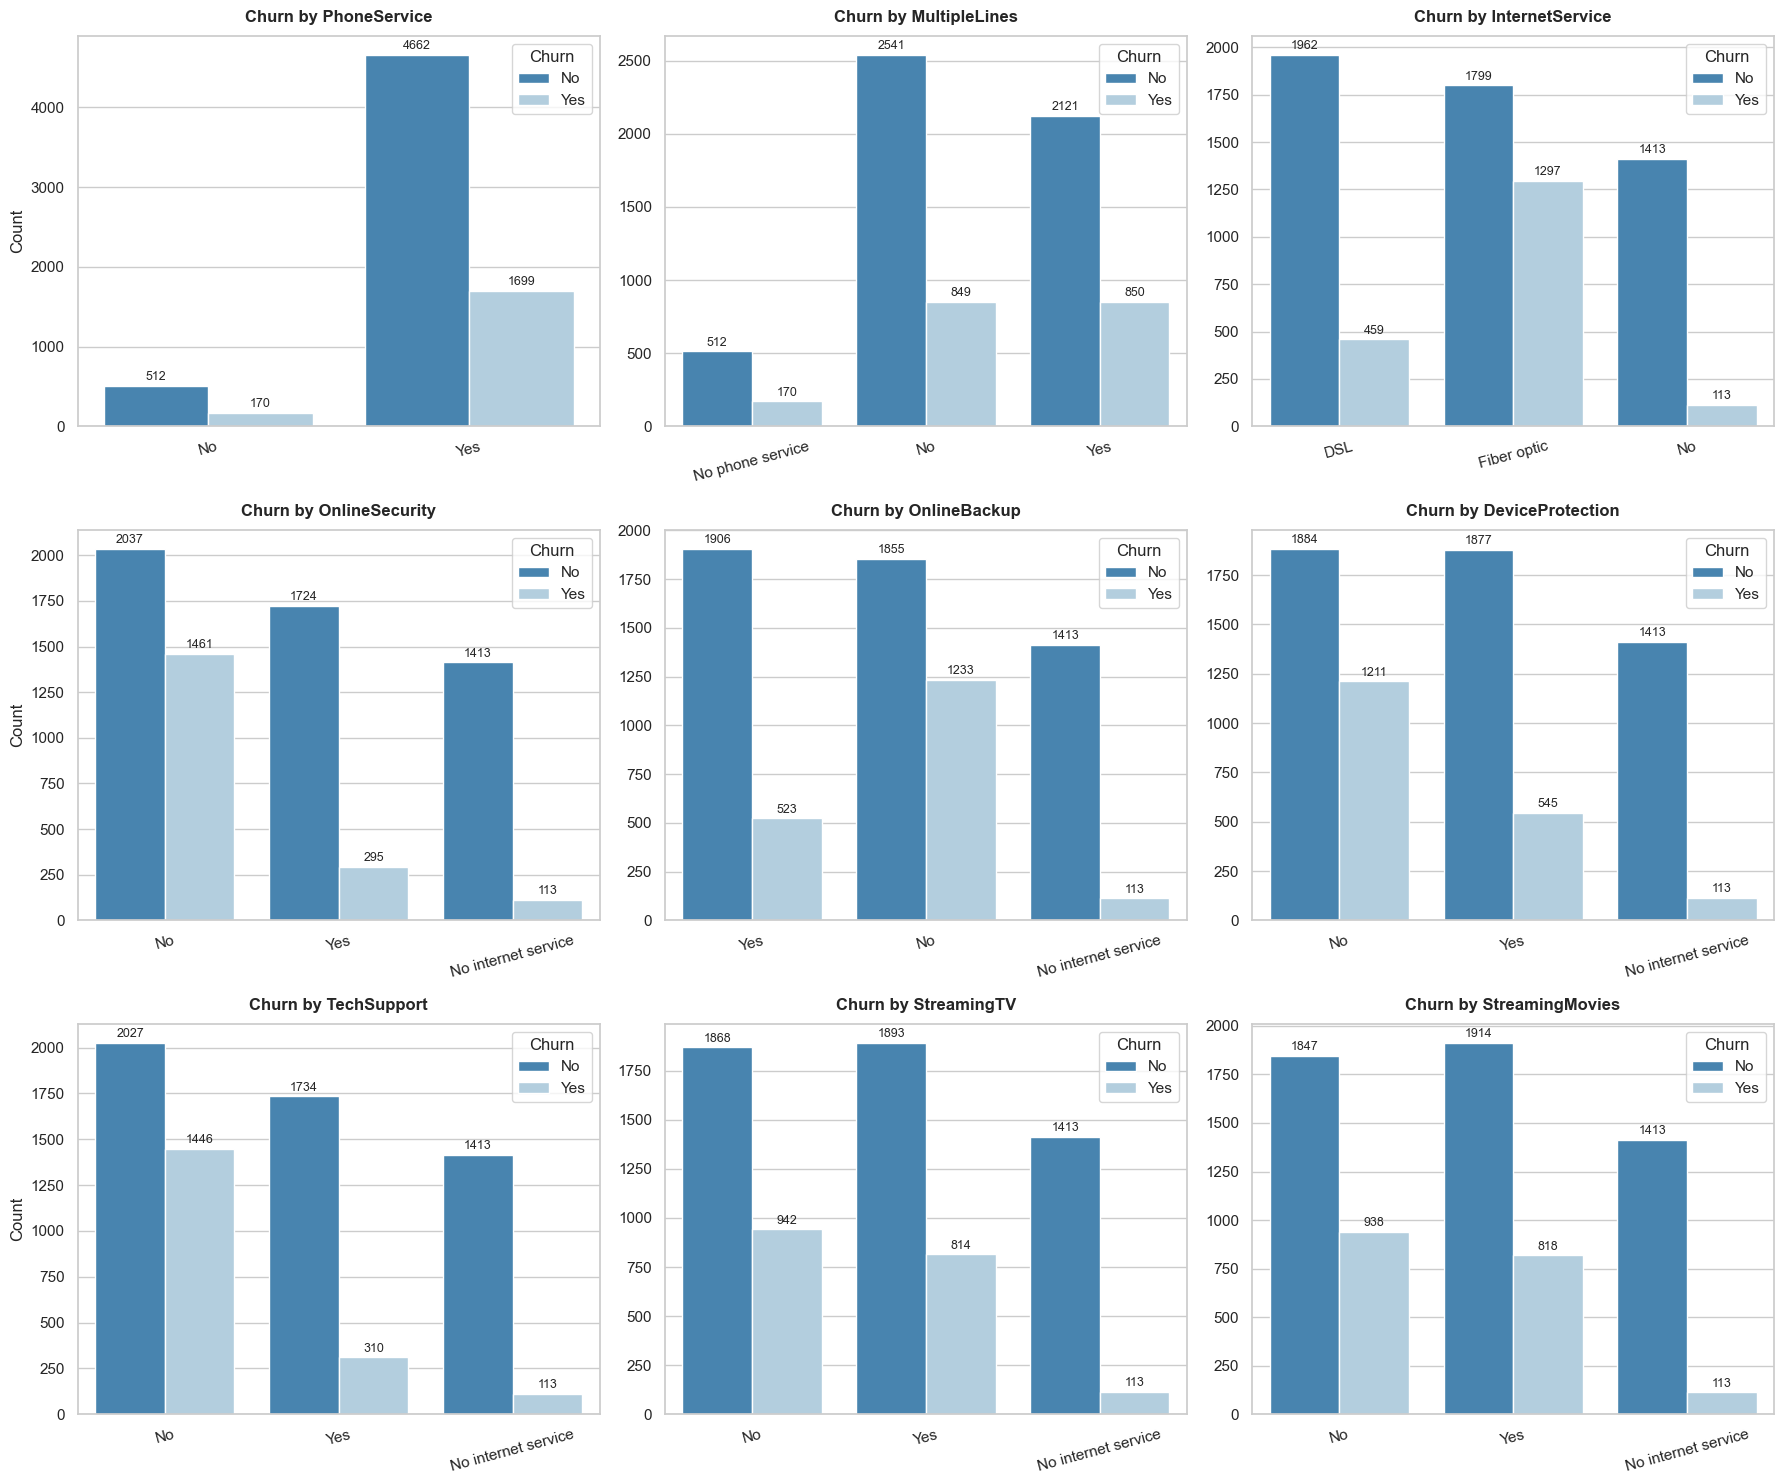

In [92]:

# 1. Define the list of service columns you want to plot
services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# 2. Set up a 3x3 subplot grid canvas
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
sns.set_theme(style='whitegrid')

# 3. Flatten the axes array to easily loop through them line-by-line
axes = axes.flatten()

# 4. Loop through each service column and its corresponding subplot axis
for i, col in enumerate(services):
    ax = sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Blues_r')
    
    # Add data labels dynamically on top of every bar
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=9)
        
    # Beautify individual subplots
    ax.set_title(f'Churn by {col}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('')  # Removes redundant x-axis labels to clean up the look
    ax.set_ylabel('Count' if i % 3 == 0 else '')  # Only show y-axis label on the leftmost plots
    ax.tick_params(axis='x', rotation=15)  # Slight angle to keep category names legible

# 5. Automatically adjust spacing so text doesn't overlap, then display
plt.tight_layout()
plt.show()

### # 📝 Observations: Product & Service Features Impact on Churn

A deep-dive into the individual service features reveals that specific product configurations act as powerful retention drivers, while others highlight severe operational pain points:

* **The Fiber Optic Paradox (Critical Finding):** * Customers with **Fiber Optic** internet service are churning at an alarmingly high rate compared to DSL users. Even though fiber optic is a premium, high-speed product, it represents a massive churn hotspot. This strongly implies issues with premium pricing, connection instability, or poor installation experiences.

* **The "Security & Support" Anchor:** * Customers who **do not** have **OnlineSecurity** or **TechSupport** exhibit massive churn volumes. Providing these two features dramatically reduces churn, indicating that technical frustration is a major trigger causing users to drop off.

* **Streaming Features are Stable:**
  * Entertainment add-ons (**StreamingTV** and **StreamingMovies**) show a highly balanced distribution. Churn rates remain consistent whether a user subscribes to them or not, meaning entertainment features are not the primary driver behind a customer's decision to leave.

* **Strategic Recommendations:**
  * **Investigate Fiber Optic:** Immediately audit the pricing model and technical performance of the Fiber Optic network to understand why premium customers are leaving.
  * **Proactive Bundling:** Consider bundling **TechSupport** and **OnlineSecurity** by default into core subscription packages (especially for Fiber Optic plans) to secure users during their high-risk early months.

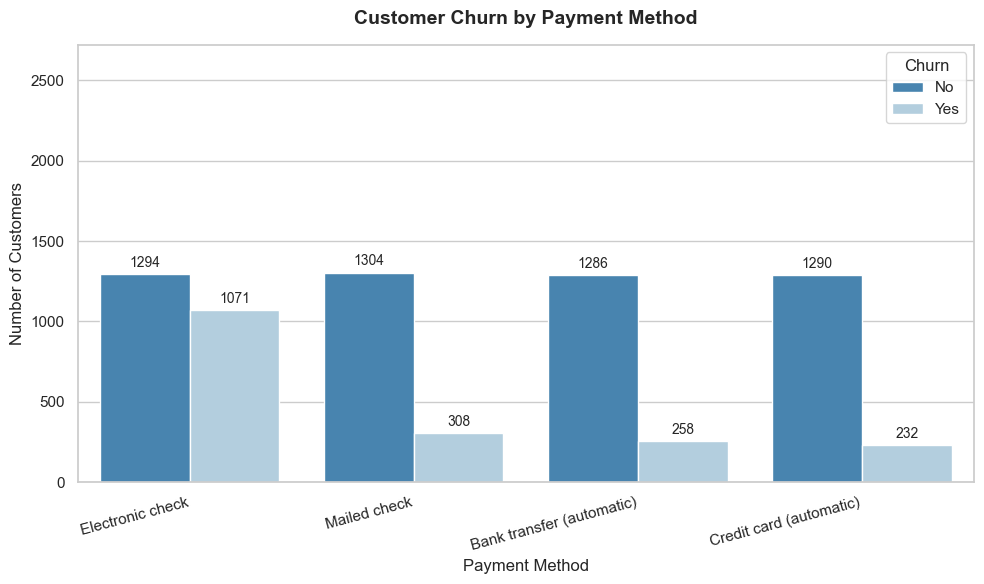

In [96]:

# Set the styling theme
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# Create the countplot with a clean color palette
ax = sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Blues_r')

# Add exact numbers on top of the bars dynamically
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

# Add clear titles and labels
plt.title('Customer Churn by Payment Method', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Fix the overlapping x-axis text by rotating the labels slightly
plt.xticks(rotation=15, ha='right')

# Give the chart top border some breathing room so numbers don't clip
plt.ylim(0, df['PaymentMethod'].value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

### # 📝 Observations & Solutions: Payment Method Impact on Churn

Analyzing how customers pay reveals a glaring risk associated with manual digital billing methods compared to automated systems:

* **The Electronic Check Risk (Critical Finding):** * Customers using **Electronic check** exhibit a catastrophic churn volume (**1,071 churned** vs. 1,294 retained). This segment accounts for the vast majority of all churned users in this category.
  * Conversely, automated payment types (**Credit card** and **Bank transfer**) alongside **Mailed check** show exceptional stability and very low attrition rates.

* **The Root Cause:** * Electronic check users must actively look at their bills and manually authorize payments every single month. This creates a recurring "transaction friction" point where customers re-evaluate their expenses and are much more likely to cancel on a whim, unlike automatic renewals.

* **Strategic Retention Solutions:**
  * **Autopay Incentives:** Launch an aggressive campaign offering a small, one-time bill credit (e.g., $5 off) if Electronic Check users switch to **Credit Card (automatic)** or **Bank Transfer (automatic)**.
  * **Smooth Onboarding:** Remove "Electronic Check" as the default option during new customer sign-ups to steer users toward auto-payment from day one.

# 📋 Project Summary: Telecom Customer Churn EDA
**Tooling:** `Python` ( `Pandas` | `Matplotlib` | `Seaborn` )

---

## 🔍 Key Findings & Insights
Our exploratory data analysis revealed several critical operational and behavioral drivers behind customer attrition:

* **The Contract Vulnerability:** Month-to-month contract customers churn at a significantly higher rate than long-term contract holders, representing a core retention risk.
* **The Electronic Check Risk:** Electronic check users exhibit the highest churn volumes. This is largely driven by recurring "transaction friction," as manual monthly payments force customers to actively re-evaluate their expenses.
* **The Fiber Optic Paradox:** Despite being a premium, high-speed product, Fiber Optic internet service is a massive churn hotspot—strongly suggesting a severe price-to-value mismatch or underlying service quality issues.
* **Demographic Vulnerabilities:** Senior citizens show noticeably higher churn rates compared to non-senior customers, pointing to potential gaps in tailored product offerings or accessibility.
* **The "Support" Anchor:** Technical frustration is a massive churn trigger; customers *without* **OnlineSecurity** or **TechSupport** add-ons are substantially more likely to drop off.

---

## 💡 Strategic Business Recommendations
To actively combat these friction points and stabilize the customer base, we recommend executing the following retention strategies:

* **Contract Migration:** Introduce targeted promotions or minor discounts to incentivize month-to-month customers to transition into stable 1-year or 2-year agreements.
* **Autopay Incentives:** Launch an aggressive campaign offering a small, one-time bill credit (e.g., $5 off) to transition Electronic Check users to automated payment methods like *Credit Card (automatic)* or *Bank Transfer (automatic)*.
* **Audit Fiber Optic Performance:** Immediately investigate pricing structures and technical stability/installation complaints surrounding the Fiber Optic network to rectify the premium product churn.
* **Proactive Security & Support Bundling:** Consider bundling *TechSupport* and *OnlineSecurity* by default into core subscription tiers (especially for high-risk segments) to secure users during critical early months.
* **Tailored Senior Campaigns:** Design specialized, high-affinity customer care pathways or simplified billing options tailored to the needs of senior citizens.